<a href="https://colab.research.google.com/github/allenphos/ML-course-ua-/blob/main/Copy_of_HW_NLP_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

pd.set_option('float_format', '{:.2f}'.format)

In [7]:
raw_df = pd.read_csv('drive/MyDrive/Colab Notebooks/data/tweet_sentiment_train.csv.zip')
raw_df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [10]:
print(raw_df.info())
print(raw_df.isna().sum())
raw_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB
None
textID           0
text             1
selected_text    1
sentiment        0
dtype: int64


,textID,text,selected_text,sentiment
count,27481,27480,27480,27481
unique,27481,27480,22463,3
top,6f7127d9d7,All this flirting going on - The ATG smiles...,good,neutral
freq,1,1,199,11118


Rows: 27 481

Columns: textID, text (1 NaN), selected_text (1 NaN), sentiment              

In [13]:
raw_df.dropna(inplace=True)

### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



In [26]:
print(raw_df['sentiment'].value_counts(normalize=True))
raw_df.sentiment.value_counts()

sentiment
neutral    0.40
positive   0.31
negative   0.28
Name: proportion, dtype: float64


,count
sentiment,
neutral,11117
positive,8582
negative,7781


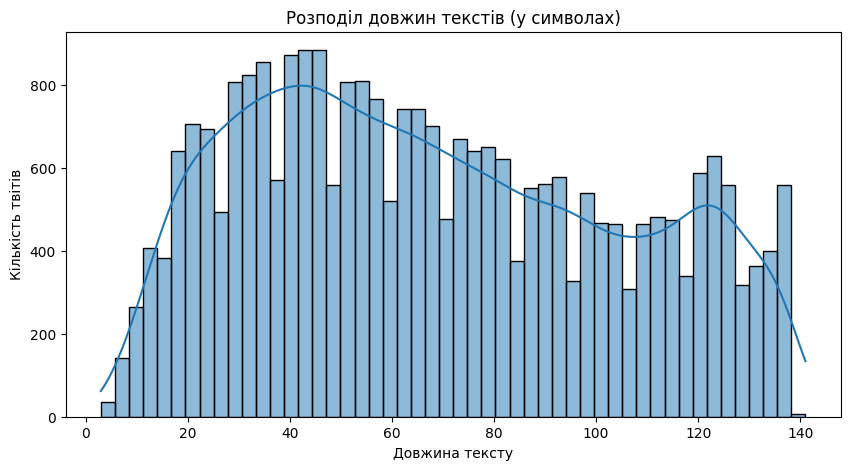

count   27480.00
mean       68.33
std        35.60
min         3.00
25%        39.00
50%        64.00
75%        97.00
max       141.00
Name: text_length, dtype: float64


In [27]:
# Обчислення довжин текстів
raw_df['text_length'] = raw_df['text'].apply(len)

# Візуалізація
plt.figure(figsize=(10, 5))
sns.histplot(raw_df['text_length'], bins=50, kde=True)
plt.title("Розподіл довжин текстів (у символах)")
plt.xlabel("Довжина тексту")
plt.ylabel("Кількість твітів")
plt.show()

# Виведення описової статистики
print(raw_df['text_length'].describe())

На графіку можно побачити, що найбільше твітів з довжиною в 30-50 символів. По статистиці медіана 64 символи, тож можна подсумувати з 30 до 70 символів використувають найчастіше.

neutral    40%
positive   31%
negative   28%

### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




In [40]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.tokenize import PunktSentenceTokenizer
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [43]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

## **токенізація (розбиття текстів на фрагменти по 1 слову)**

In [39]:
q0 = raw_df[raw_df.sentiment == 'positive'].text.values[1]
q0

' Journey!? Wow... u just became cooler.  hehe... (is that possible!?)'

In [38]:
q1 = raw_df[raw_df.sentiment == 'negative'].text.values[1]
q1

'my boss is bullying me...'

In [44]:
q0_tok = word_tokenize(q0)
q1_tok = word_tokenize(q1)

In [45]:
q0_tok

['Journey',
 '!',
 '?',
 'Wow',
 '...',
 'u',
 'just',
 'became',
 'cooler',
 '.',
 'hehe',
 '...',
 '(',
 'is',
 'that',
 'possible',
 '!',
 '?',
 ')']

## **видалення stopwords необхідної мови**

In [41]:
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [46]:
english_stopwords = stopwords.words('english')

In [47]:
", ".join(english_stopwords)

"a, about, above, after, again, against, ain, all, am, an, and, any, are, aren, aren't, as, at, be, because, been, before, being, below, between, both, but, by, can, couldn, couldn't, d, did, didn, didn't, do, does, doesn, doesn't, doing, don, don't, down, during, each, few, for, from, further, had, hadn, hadn't, has, hasn, hasn't, have, haven, haven't, having, he, he'd, he'll, her, here, hers, herself, he's, him, himself, his, how, i, i'd, if, i'll, i'm, in, into, is, isn, isn't, it, it'd, it'll, it's, its, itself, i've, just, ll, m, ma, me, mightn, mightn't, more, most, mustn, mustn't, my, myself, needn, needn't, no, nor, not, now, o, of, off, on, once, only, or, other, our, ours, ourselves, out, over, own, re, s, same, shan, shan't, she, she'd, she'll, she's, should, shouldn, shouldn't, should've, so, some, such, t, than, that, that'll, the, their, theirs, them, themselves, then, there, these, they, they'd, they'll, they're, they've, this, those, through, to, too, under, until, up, 

In [48]:
def remove_stopwords(tokens):
    return [word for word in tokens if word.lower() not in english_stopwords]

In [50]:
q0_stp = remove_stopwords(q0_tok)
q0_stp

['Journey',
 '!',
 '?',
 'Wow',
 '...',
 'u',
 'became',
 'cooler',
 '.',
 'hehe',
 '...',
 '(',
 'possible',
 '!',
 '?',
 ')']

In [51]:
q1_stp = remove_stopwords(q1_tok)
q1_stp

['boss', 'bullying', '...']

## **стеммінг слів зі SnowballStemmer**

In [52]:
from nltk.stem.snowball import SnowballStemmer

stemmer = SnowballStemmer(language='english')

In [53]:
q0_stm = [stemmer.stem(word) for word in q0_stp]
q0_stm

['journey',
 '!',
 '?',
 'wow',
 '...',
 'u',
 'becam',
 'cooler',
 '.',
 'hehe',
 '...',
 '(',
 'possibl',
 '!',
 '?',
 ')']

In [54]:
q1_stm = [stemmer.stem(word) for word in q1_stp]
q1_stm

['boss', 'bulli', '...']

## **Створення словника з sklearn.feature_extraction.text.CountVectorizer**

За замовченням CountVectorizer робить таке:
Токенізує текст — розбиває на окремі слова за пробілами та базовими знаками пунктуації.

Нижній регістр — всі слова переводить у нижній регістр (lowercase=True).

Ігнорує пунктуацію та числа (переважно).

Створює словник (всі унікальні слова з корпусу).

Будує частотну матрицю:

Рядки — документи (твіти),

Стовпці — слова з цього словника,

Значення — скільки разів слово зустрічається в документі.

In [56]:
raw_df.text.values

array([' I`d have responded, if I were going',
       ' Sooo SAD I will miss you here in San Diego!!!',
       'my boss is bullying me...', ...,
       ' Yay good for both of you. Enjoy the break - you probably need it after such hectic weekend  Take care hun xxxx',
       ' But it was worth it  ****.',
       '   All this flirting going on - The ATG smiles. Yay.  ((hugs))'],
      dtype=object)

In [63]:
from sklearn.feature_extraction.text import CountVectorizer

raw_vect = CountVectorizer()

raw_vect_fit = raw_vect.fit(raw_df.text)

raw_vect.get_feature_names_out()[10000:10010]

array(['forgotten', 'forgottten', 'fork', 'forked', 'form', 'formal',
       'formally', 'format', 'former', 'formidable'], dtype=object)

## pipeline попередньої обробки тексту та векторизації методом Bag of Words

In [76]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
from sklearn.feature_extraction.text import CountVectorizer
import re

# --- Підготовка NLTK ---
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

# --- Компоненти попередньої обробки ---
english_stopwords = set(stopwords.words('english'))
stemmer = SnowballStemmer("english")

def reduce_lengthening(text):
    return re.sub(r"(.)\1{2,}", r"\1\1", text)

def clean_text(text):
    text = re.sub(r"[^a-zA-Z]", " ", text)                  # видаляємо все, що не букви
    text = reduce_lengthening(text)                         # нормалізація повторів
    tokens = word_tokenize(text)
    tokens = [word.lower() for word in tokens if word.lower() not in english_stopwords]
    stems = [stemmer.stem(word) for word in tokens]
    return " ".join(stems)

# --- Застосування очищення ---
raw_df["cleaned_text"] = raw_df["text"].astype(str).apply(clean_text)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


**унікальні слова після обробки**

In [77]:
# --- Аналіз унікальних слів ---

from collections import Counter

# Обʼєднуємо всі оброблені тексти в один рядок
all_words = " ".join(raw_df["cleaned_text"]).split()

# Порахуємо кількість повторень кожного слова
word_counts = Counter(all_words)

print(f"Кількість унікальних слів: {len(word_counts)}")

Кількість унікальних слів: 18928


<ipython-input-78-5f001ea7fbc7>:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


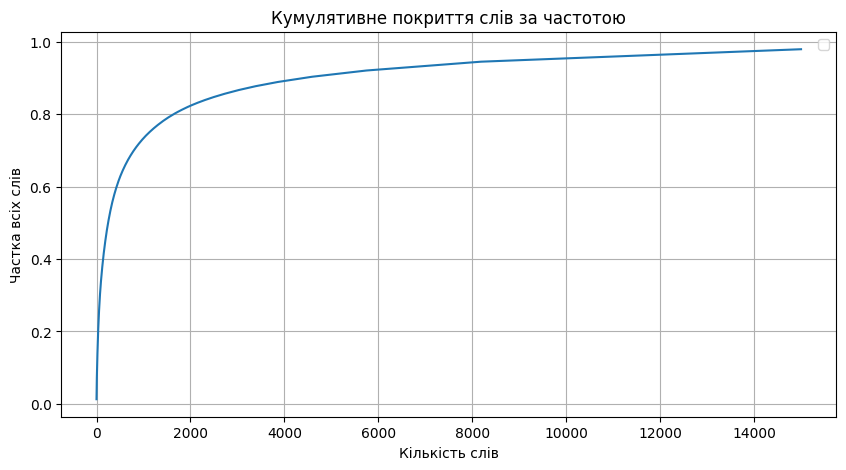

In [78]:
# Отримаємо частоти
sorted_counts = sorted(word_counts.values(), reverse=True)

# Кумулятивна сума
cum_sum = np.cumsum(sorted_counts) / sum(sorted_counts)

# Побудуємо графік
plt.figure(figsize=(10,5))
plt.plot(cum_sum[:15000])  # максимум — 15 тис слів
plt.title("Кумулятивне покриття слів за частотою")
plt.xlabel("Кількість слів")
plt.ylabel("Частка всіх слів")
plt.grid(True)
#plt.axvline(x=5000, color='red', linestyle='--', label='TOP 5000')
plt.legend()
plt.show()


На осі X — кількість унікальних слів.

На осі Y — яку частку всіх вживань вони покривають.

## Функція для аналізу оптимального TOP_N_WORDS

In [79]:
def analyze_top_words_coverage(texts, thresholds=[0.9, 0.95, 0.99]):
    """
    texts: список очищених текстів (наприклад, raw_df['cleaned_text'])
    thresholds: список часток, які хочемо покрити (наприклад, 90%, 95% тощо)
    """
    # Збираємо всі слова в один список
    all_words = " ".join(texts).split()
    word_counts = Counter(all_words)

    print(f"Загальна кількість унікальних слів: {len(word_counts)}")

    # Сортуємо частоти у спадаючому порядку
    sorted_counts = sorted(word_counts.values(), reverse=True)

    # Кумулятивна сума
    total = sum(sorted_counts)
    cum_sum = np.cumsum(sorted_counts) / total

    # Графік
    plt.figure(figsize=(10, 5))
    plt.plot(cum_sum[:10000])
    for thresh in thresholds:
        idx = np.argmax(cum_sum >= thresh)
        plt.axvline(x=idx, linestyle='--', label=f"{int(thresh*100)}% @ {idx} слів")
    plt.title("Кумулятивне покриття слів за частотою")
    plt.xlabel("Кількість найбільш частих слів")
    plt.ylabel("Частка всіх токенів")
    plt.grid(True)
    plt.legend()
    plt.show()

    # Текстовий результат
    for thresh in thresholds:
        idx = np.argmax(cum_sum >= thresh)
        print(f"{int(thresh*100)}% корпусу покривають {idx} слів.")


Загальна кількість унікальних слів: 18928


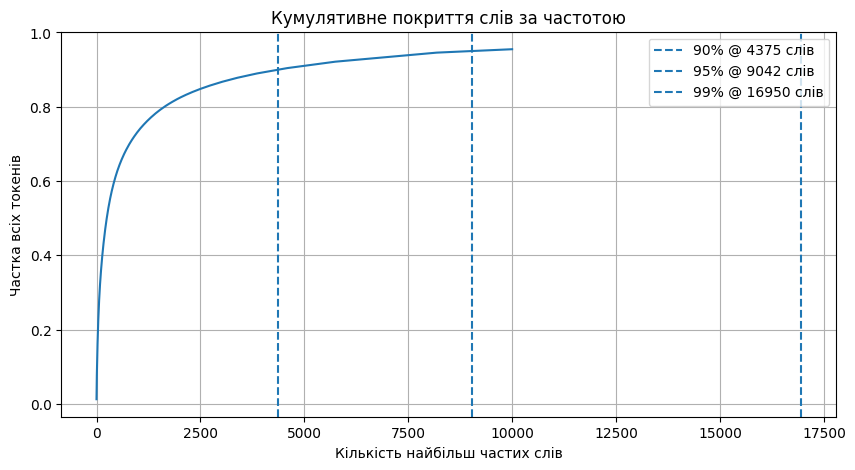

90% корпусу покривають 4375 слів.
95% корпусу покривають 9042 слів.
99% корпусу покривають 16950 слів.


In [80]:
analyze_top_words_coverage(raw_df['cleaned_text'])

In [85]:
%%time
# Візьмемо топ-9000 слів
TOP_N_WORDS = 9000

# --- Векторизація ---
vectorizer = CountVectorizer(max_features=TOP_N_WORDS)
X_bow = vectorizer.fit_transform(raw_df["cleaned_text"])

# --- Результат ---
print(f"Матриця ознак має форму: {X_bow.shape}")
print(f"Приклади ознак: {vectorizer.get_feature_names_out()[:10]}")

Матриця ознак має форму: (27480, 9000)
Приклади ознак: ['aa' 'aaah' 'aaahh' 'aaand' 'aaargh' 'aaarrgh' 'aaaw' 'aac' 'aafternoon'
 'aaggess']
CPU times: user 564 ms, sys: 103 µs, total: 565 ms
Wall time: 609 ms


### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



In [87]:
from sklearn.model_selection import train_test_split

X_train_bow, X_test_bow, y_train, y_test = train_test_split(X_bow, raw_df.sentiment,
                                                                        test_size=0.3, random_state=42)

In [103]:
from sklearn.linear_model import LogisticRegression

MAX_ITER = 1000

model = LogisticRegression(max_iter=MAX_ITER, solver='sag', class_weight='balanced')

In [104]:
%%time
# Convert y_train to a dense numpy array before fitting the model
model.fit(X_train_bow, y_train.values) # use .values to convert to numpy array

CPU times: user 1.06 s, sys: 956 µs, total: 1.06 s
Wall time: 1.06 s


LogisticRegression(class_weight='balanced', max_iter=1000, solver='sag')

In [105]:
train_preds = model.predict(X_train_bow)

In [93]:
y_train

,sentiment
21912,neutral
24541,negative
26263,neutral
22394,neutral
27323,negative
...,...
21576,neutral
5391,neutral
861,neutral
15796,positive


In [94]:
train_preds

array(['neutral', 'negative', 'neutral', ..., 'neutral', 'neutral',
       'positive'], dtype=object)

In [108]:
pd.Series(train_preds).value_counts(normalize=True)

,proportion
neutral,0.39
positive,0.32
negative,0.29


🔹 Logistic Regression Classification Report:
              precision    recall  f1-score   support

    negative       0.67      0.65      0.66      2356
     neutral       0.66      0.66      0.66      3343
    positive       0.73      0.75      0.74      2545

    accuracy                           0.68      8244
   macro avg       0.69      0.69      0.69      8244
weighted avg       0.68      0.68      0.68      8244



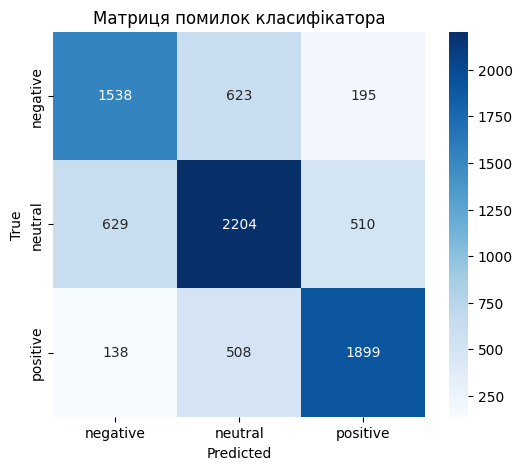

In [109]:
from sklearn.metrics import classification_report, confusion_matrix
# Передбачення
y_pred = model.predict(X_test_bow)

# 4. Звіт
print("🔹 Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred, target_names=['negative', 'neutral', 'positive']))

# 5. Матриця помилок
cm = confusion_matrix(y_test, y_pred, labels=['negative', 'neutral', 'positive'])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Матриця помилок класифікатора")
plt.show()

629 neutral твітів помилково класифіковані як negative — модель часто плутає ці класи.

508 positive твітів класифіковані як neutral

accuracy 0.68

In [102]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report # import accuracy_score

tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train_bow, y_train)

y_pred_tree = tree.predict(X_test_bow)

print("🔹 Decision Tree:")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

🔹 Decision Tree:
Accuracy: 0.6582969432314411
              precision    recall  f1-score   support

    negative       0.63      0.63      0.63      2356
     neutral       0.65      0.63      0.64      3343
    positive       0.69      0.72      0.71      2545

    accuracy                           0.66      8244
   macro avg       0.66      0.66      0.66      8244
weighted avg       0.66      0.66      0.66      8244



accuracy   0.66      

Трохи краще модель логістичної регресії з 0.68.


Зберігання vectorizer і model

In [110]:
import joblib

joblib.dump(vectorizer, "bow_vectorizer.pkl")
joblib.dump(model, "logreg_model.pkl")

#vectorizer = joblib.load("bow_vectorizer.pkl")
#model = joblib.load("logreg_model.pkl")

['logreg_model.pkl']

In [113]:
print(model.classes_)

['negative' 'neutral' 'positive']


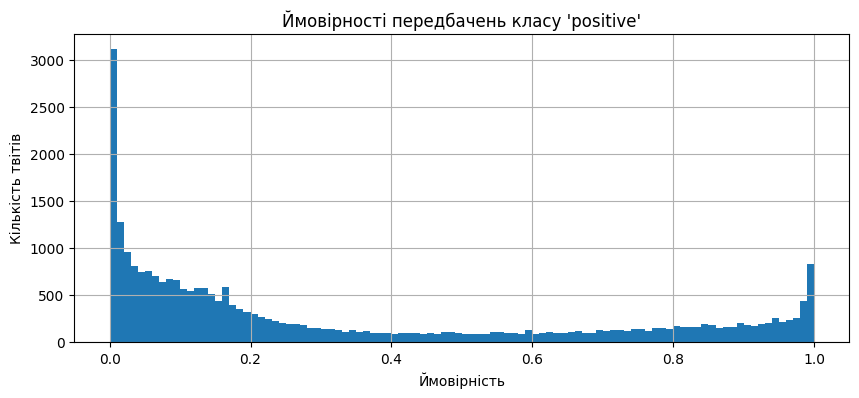

In [114]:
raw_df['prediction_proba_positive'] = model.predict_proba(X_bow)[:, 2]

# Побудова гістограми
raw_df['prediction_proba_positive'].hist(bins=100, figsize=(10,4))
plt.title("Ймовірності передбачень класу 'positive'")
plt.xlabel("Ймовірність")
plt.ylabel("Кількість твітів")
plt.show()

Графік зміщений до 0 та до 1 — модель досить впевнена у своїх передбаченнях

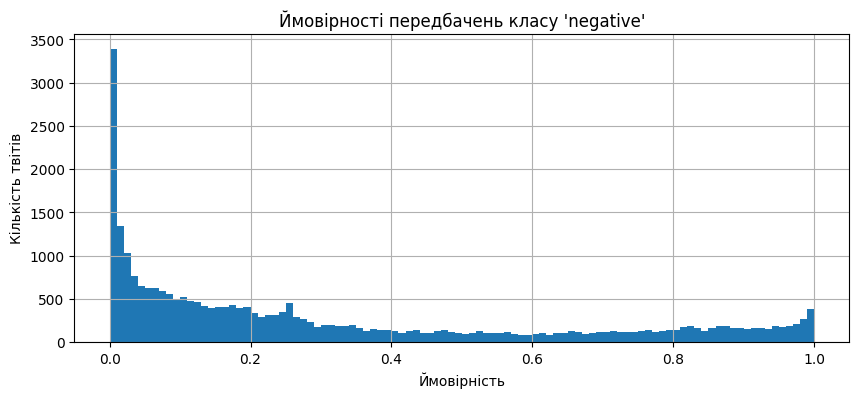

In [121]:
raw_df['prediction_proba_negative'] = model.predict_proba(X_bow)[:, 0]

# Побудова гістограми
raw_df['prediction_proba_negative'].hist(bins=100, figsize=(10,4))
plt.title("Ймовірності передбачень класу 'negative'")
plt.xlabel("Ймовірність")
plt.ylabel("Кількість твітів")
plt.show()

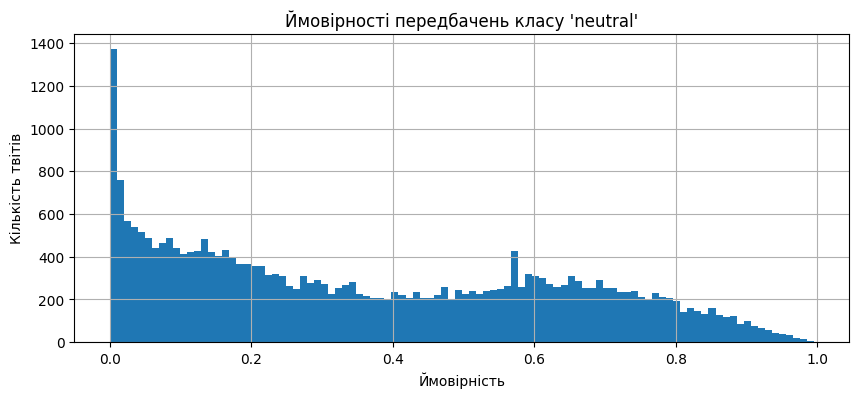

In [117]:
raw_df['prediction_proba_neutral'] = model.predict_proba(X_bow)[:, 1]

# Побудова гістограми
raw_df['prediction_proba_neutral'].hist(bins=100, figsize=(10,4))
plt.title("Ймовірності передбачень класу 'neutral'")
plt.xlabel("Ймовірність")
plt.ylabel("Кількість твітів")
plt.show()

Модель не дуже впевнена у передбаченнях для neutral

In [119]:
for threshold in [0.1, 0.2, 0.3, 0.5, 0.7]:
    count = (raw_df['prediction_proba_neutral'] > threshold).sum()
    print(f"Поріг {threshold}: {count} твітів передбачено як 'neutral'")

Поріг 0.1: 21388 твітів передбачено як 'neutral'
Поріг 0.2: 17239 твітів передбачено як 'neutral'
Поріг 0.3: 14169 твітів передбачено як 'neutral'
Поріг 0.5: 9588 твітів передбачено як 'neutral'
Поріг 0.7: 4042 твітів передбачено як 'neutral'


 Чим нижчий поріг, тим більше твітів вважаються neutral (навіть з низькою впевненістю).

Чим вищий поріг, тим менше твітів проходять фільтр — але модель більш впевнена в цих передбаченнях.

In [130]:
from sklearn.metrics import f1_score

raw_df['true_neutral'] = raw_df['sentiment'] == 'neutral'

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred = raw_df['prediction_proba_neutral'] > threshold
    f1 = f1_score(raw_df['true_neutral'], y_pred)
    print(f"Поріг: {threshold}, F1: {f1:.3f}")

Поріг: 0.3, F1: 0.775
Поріг: 0.4, F1: 0.793
Поріг: 0.5, F1: 0.769
Поріг: 0.6, F1: 0.667
Поріг: 0.7, F1: 0.481


In [131]:
probas = model.predict_proba(X_bow)
class_names = model.classes_

In [132]:
import numpy as np

neutral_index = np.where(class_names == 'neutral')[0][0]
custom_preds = []

for i in range(len(probas)):
    # Якщо ймовірність нейтрального класу > 0.4 — вважаємо твіт нейтральним
    if probas[i][neutral_index] > 0.4:
        custom_preds.append('neutral')
    else:
        # Інакше беремо той клас, що має найбільшу ймовірність
        pred_class = class_names[np.argmax(probas[i])]
        custom_preds.append(pred_class)


In [133]:
from sklearn.metrics import classification_report

print(classification_report(raw_df['sentiment'], custom_preds))

              precision    recall  f1-score   support

    negative       0.82      0.76      0.79      7781
     neutral       0.77      0.82      0.79     11117
    positive       0.84      0.81      0.83      8582

    accuracy                           0.80     27480
   macro avg       0.81      0.80      0.80     27480
weighted avg       0.80      0.80      0.80     27480



Вдалось покращити точність моделі до 0.80 з порогом класифікації для нейтральних текстів 0.4

In [138]:
threshold = 0.4
raw_df[f'predicted_neutral_{threshold}'] = raw_df['prediction_proba_neutral'] > threshold

In [139]:
raw_df['error'] = raw_df['true_neutral'] != raw_df[f'predicted_neutral_0.4']

In [140]:
neutral_errors = raw_df[(raw_df['error']) & (raw_df['true_neutral'])]

# Подивимось важливі стовпці:
neutral_errors[['text', 'sentiment', 'prediction_proba_neutral', f'predicted_neutral_{threshold}']]


,text,sentiment,prediction_proba_neutral,predicted_neutral_0.4
5,http://www.dothebouncy.com/smf - some shameles...,neutral,0.27,False
43,RATT ROCKED NASHVILLE TONITE..ONE THING SUCKED...,neutral,0.39,False
51,"also bored at school, its my third freelesson...",neutral,0.20,False
59,what fun are you speaking of?,neutral,0.33,False
87,His snoring is so annoying n it keeps me from ...,neutral,0.34,False
...,...,...,...,...
27404,all tubes closed on 9th and 10th of june any...,neutral,0.34,False
27408,Just got home from the BEA & it was kinda bori...,neutral,0.35,False
27418,he calls me bella,neutral,0.40,False
27466,Naw.. it was pretty tame. Only 1 guy in costu...,neutral,0.09,False


In [142]:
raw_df[(raw_df['error']) & (~raw_df['true_neutral'])]

,textID,text,selected_text,sentiment,text_length,cleaned_text,prediction_proba_positive,prediction_proba_neutral,prediction_proba_negative,prediction_neutral_0.4,prediction_neutral_0.5,true_neutral,predicted_neutral_0.4,error
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,75,son put releas alreadi bought,0.51,0.51,0.28,True,True,False,True,True
16,3440297f8b,"S`ok, trying to plot alternatives as we speak...",*sigh*,negative,53,ok tri plot altern speak sigh,0.51,0.51,0.45,True,True,False,True,True
17,919fa93391,i`ve been sick for the past few days and thus...,sick,negative,137,sick past day thus hair look wierd didnt hat w...,0.68,0.68,0.28,True,True,False,True,True
27,bdc32ea43c,On the way to Malaysia...no internet access to...,.no internet,negative,51,way malaysia internet access twit,0.43,0.43,0.52,True,False,False,True,True
29,d22e6d40a7,Went to sleep and there is a power cut in Noid...,Power back up not working too,negative,78,went sleep power cut noida power back work,0.71,0.71,0.24,True,True,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27420,24fa941c24,I would but you`re too far away,too far away,negative,32,would far away,0.55,0.55,0.29,True,True,False,True,True
27438,9057950ae4,Where is my bestie when i need him,Where is my bestie when i need him,negative,35,besti need,0.46,0.46,0.24,True,False,False,True,True
27439,ecfc3c4122,I am beginning to think sun blcok is a haox.,haox.,negative,44,begin think sun blcok haox,0.56,0.56,0.28,True,True,False,True,True
27440,7fd422900b,I GET IT. YOU ESPLAINED IT TO ME AWHILE AGO.,I GET IT.,negative,46,get esplain awhil ago,0.57,0.57,0.25,True,True,False,True,True


### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


In [144]:
feature_importance = pd.Series(model.coef_[0], index=vectorizer.get_feature_names_out(), name='imp').sort_values(ascending=False)
feature_importance

,imp
sad,2.53
suck,2.44
bore,2.40
sorri,2.24
hate,2.17
...,...
congrat,-1.87
love,-1.92
cute,-1.93
glad,-2.13


формула сигмоїдної функції, показує, як перетворити лінійний результат (логіт) у ймовірність.

In [145]:
import numpy

1/(1+np.exp(-(10)))

np.float64(0.9999546021312976)

неекологічні

In [146]:
feature_importance[:10]

,imp
sad,2.53
suck,2.44
bore,2.40
sorri,2.24
hate,2.17
miss,2.14
disappoint,2.05
fail,2.01
shame,1.99
exhaust,1.92


sad bore sorri miss не можна сказати що це прям токсичні слова, але в цілому зрозуміло що настрій в них негативний.

ці слова зменшують ймовірність що питання неекологічне/токсичне - тобто позитивні або нейтральні

In [148]:
feature_importance[-10:]

,imp
smile,-1.60
enjoy,-1.66
bless,-1.70
welcom,-1.70
thank,-1.83
congrat,-1.87
love,-1.92
cute,-1.93
glad,-2.13
awesom,-2.39


### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



In [166]:
from sklearn.feature_extraction.text import TfidfVectorizer

TOP_N_WORDS = 9000

tfidf_vectorizer = TfidfVectorizer(max_features=TOP_N_WORDS)

X_tfidf = tfidf_vectorizer.fit_transform(raw_df['cleaned_text'])

print("TF-IDF матриця має розмір:", X_tfidf.shape)
print("Приклад слів:", tfidf_vectorizer.get_feature_names_out()[:10])

TF-IDF матриця має розмір: (27480, 9000)
Приклад слів: ['aa' 'aaah' 'aaahh' 'aaand' 'aaargh' 'aaarrgh' 'aaaw' 'aac' 'aafternoon'
 'aaggess']


індекси train/test

In [167]:
train_idx, test_idx = train_test_split(
    raw_df.index, test_size=0.3, random_state=42)

train/test за тими ж індексами

In [168]:
X_train_tfidf = X_tfidf[train_idx.values - X_tfidf.shape[0]]
X_test_tfidf = X_tfidf[test_idx.values - X_tfidf.shape[0]]

y_train_tfidf = raw_df.loc[train_idx, 'sentiment']
y_test_tfidf = raw_df.loc[test_idx, 'sentiment']

In [169]:
model_tfidf = LogisticRegression(max_iter=1000, solver='sag')
model_tfidf.fit(X_train_tfidf, y_train_tfidf)

y_pred_tfidf = model_tfidf.predict(X_test_tfidf)

print(classification_report(y_test_tfidf, y_pred_tfidf))

              precision    recall  f1-score   support

    negative       0.29      0.15      0.20      2356
     neutral       0.40      0.59      0.48      3343
    positive       0.31      0.25      0.27      2545

    accuracy                           0.36      8244
   macro avg       0.33      0.33      0.32      8244
weighted avg       0.34      0.36      0.34      8244



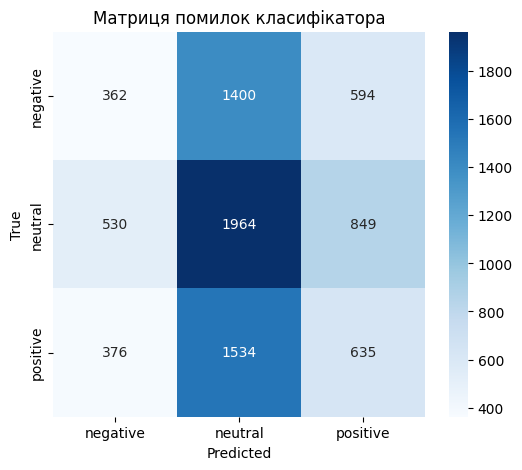

In [157]:
# 5. Матриця помилок
cm = confusion_matrix(y_test_tfidf, y_pred_tfidf, labels=['negative', 'neutral', 'positive'])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Матриця помилок класифікатора")
plt.show()

TF-IDF набагато гірша ніж BOW. 0.36 accuracy

TF-IDF може глушить часті слова, які могли бути інформативними та часто гірше працює на коротких текстах, як твіти. Тому що важко вирахувати унікальність коли мало слів.


In [172]:
feature_importance = pd.Series(model.coef_[0], index=tfidf_vectorizer.get_feature_names_out(), name='imp').sort_values(ascending=False)
feature_importance

,imp
sad,2.53
suck,2.44
bore,2.40
sorri,2.24
hate,2.17
...,...
congrat,-1.87
love,-1.92
cute,-1.93
glad,-2.13


In [175]:
feature_importance[:10]

,imp
sad,2.53
suck,2.44
bore,2.40
sorri,2.24
hate,2.17
miss,2.14
disappoint,2.05
fail,2.01
shame,1.99
exhaust,1.92


In [176]:
feature_importance[-10:]

,imp
smile,-1.60
enjoy,-1.66
bless,-1.70
welcom,-1.70
thank,-1.83
congrat,-1.87
love,-1.92
cute,-1.93
glad,-2.13
awesom,-2.39


Найвпливовіші токени у обох методах векторізіції однакові.

BOW набагато краще себе показав в багатокласовій класифікації дивлячись на accuracy та на confusion matrix.

### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

In [177]:
# Створюємо датафрейм з індексами тестових зразків
error_df = raw_df.loc[test_idx].copy()

# Додаємо передбачення
error_df['predicted'] = y_pred_tfidf

# Позначаємо помилки
error_df['error'] = error_df['sentiment'] != error_df['predicted']

# Виводимо лише ті рядки, де класифікатор помилився
errors_only = error_df[error_df['error']]

# Подивимось перші кілька прикладів
errors_only[['text', 'sentiment', 'predicted']].head(10)

,text,sentiment,predicted
1589,Enjoy! Family trumps everything,positive,neutral
10414,--of them kinda turns me off of it all. And ...,negative,neutral
4004,is texting,neutral,positive
1570,Do you have any idea when the (not so) patien...,neutral,positive
8286,"Ooooh, I`m jealous I might try and get some ...",negative,positive
580,OHSHNAPSSS. is she pissed at blair as usual ?...,neutral,positive
9189,wee. done with advance audit paper,neutral,positive
6700,good job!,positive,neutral
25014,oooh sounds yummy. If you get a chance to ta...,positive,neutral
9797,Could be useful 13 Tutorials & Resources for ...,positive,neutral


Класифікатор при векторизації TF-IDF часто плутає positive	з neutral та навпаки, та трохи складно ідентифікує негативні класи.

In [178]:
# Які саме класи найчастіше плутає модель
confused = errors_only.groupby(['sentiment', 'predicted']).size().reset_index(name='count')
confused = confused.sort_values(by='count', ascending=False)
print(confused.head(10))


  sentiment predicted  count
5  positive   neutral   1533
0  negative   neutral   1400
3   neutral  positive    849
1  negative  positive    594
2   neutral  negative    530
4  positive  negative    377


1. Можна змінити поріг класифікатора для всіх класів, але треба розглядати індивідуально кожен клас.

2. Додати емоційні словники, створити нові ознаки, щоб модель краще розпізнавала позитивні та негативні класи.

3. Можна натренувати більш складну модель, ніж логістична регресія та використовувати більше методів машинного навчання для підвищення якості класифікації.

І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model